# ESP 3-D velocity-field reconstruction

This notebook demonstrates how well the elliptical streamfunction parameterisation (ESP) reconstructs one SEACOFS eddy from its depth-dependent fitted parameters.

It resolves the original monthly NetCDF file from `fname`, applies the same depth interpolation and grid rotation used by the pipeline, evaluates ESP on the native grid, and compares maps, vertical sections, depth-resolved skill, 3-D velocity vectors, and normalised Okubo–Weiss isosurfaces.

By default, a depth-dependent outer-ring background flow is removed from SEACOFS before comparison. This is important because ESP represents the coherent eddy component, not the full regional circulation.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import netCDF4 as nc
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
from scipy.stats import pearsonr

HERE = Path.cwd()
PROJECT_ROOT = HERE.parent if HERE.name == "notebooks" else HERE
for path in (PROJECT_ROOT / "src", PROJECT_ROOT.parent / "seacofs_eddy_tilt_analysis"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import seacofs_tilt_tools as tilt
from seacofs_eddy_dataset.core.velocity import rotate_uv
from seacofs_eddy_dataset.core.vertical import interp_3d_to_reference_depths

ESP_ROOT = Path("/home/z5297792/ESP_zonodo")
if str(ESP_ROOT) not in sys.path:
    sys.path.insert(0, str(ESP_ROOT))
import functions as esp

sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300})

# Change these controls for another case.
EDDY_ID = 6 #None
DAY = 1470 #None
DEPTH_TO_PLOT = 100.0
HALF_WIDTH_RC = 2.25
MIN_HALF_WIDTH_KM = 80.0
REMOVE_BACKGROUND = True
BACKGROUND_INNER_FRAC = 0.72
QUIVER_STEP = 5
OW_THRESHOLD = -0.2
SAVE_FIGURES = False

FIGURE_DIR = PROJECT_ROOT / "figures" / "esp_velocity_reconstruction"
if SAVE_FIGURES:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, _ = tilt.load_tilt_tables(paths)
df_vert = tilt.load_vert(paths, dic_form=False)


## Select a well-resolved eddy-day and locate its source file

Set `EDDY_ID` and `DAY` above for a specific case. Otherwise the deepest valid fitted profile is selected automatically.


In [2]:
def choose_case(surface, vertical, eddy_id=None, day=None):
    needed = ["Depth", "xc", "yc", "Rc", "Omega", "q11", "q12", "q22"]
    valid = vertical.dropna(subset=needed)
    counts = valid.groupby(["Eddy", "Day"]).Depth.agg(["count", "max"]).reset_index()
    if eddy_id is not None:
        counts = counts[counts.Eddy == eddy_id]
    if day is not None:
        counts = counts[counts.Day == day]
    if counts.empty:
        raise ValueError("No valid profile matches EDDY_ID and DAY.")
    choice = counts.sort_values(["max", "count"], ascending=False).iloc[0]
    profile = (valid[(valid.Eddy == choice.Eddy) & (valid.Day == choice.Day)]
               .sort_values("Depth").drop_duplicates("Depth").reset_index(drop=True))
    row = surface[(surface.Eddy == choice.Eddy) & (surface.Day == choice.Day)].iloc[0]
    return row, profile


def resolve_model_file(row):
    supplied = Path(str(row.fname)).expanduser()
    candidates = [
        supplied,
        paths.grid.parent / supplied.name,
        Path("/srv/scratch/z3533156/26year_BRAN2020") / supplied.name,
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find {supplied.name}. Checked:\n" +
        "\n".join(f"  - {path}" for path in candidates)
    )


surface, profile = choose_case(df_eddies, df_vert, EDDY_ID, DAY)
model_file = resolve_model_file(surface)
display(pd.Series({
    "Eddy": int(surface.Eddy), "Day": int(surface.Day),
    "Polarity": getattr(surface, "Cyc", ""),
    "Fitted depths": len(profile), "Maximum depth (m)": profile.Depth.max(),
    "NetCDF": model_file,
}).to_frame("value"))


,value
Eddy,6
Day,1470
Polarity,AE
Fitted depths,29
Maximum depth (m),4460.447022
NetCDF,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


## Load SEACOFS and reconstruct ESP

Coordinates are kilometres and velocities are m s$^{-1}$. SEACOFS velocities are transformed exactly as in the modular vertical-profile pipeline. ESP is evaluated directly on the same native grid points, without horizontal interpolation.


In [3]:
def model_time_index(dataset, day):
    days = np.asarray(dataset["ocean_time"][:], float) / 86400
    index = int(np.argmin(np.abs(days - day)))
    if not np.isclose(days[index], day, atol=1e-5):
        raise KeyError(f"Day {day} is absent from {Path(dataset.filepath()).name}.")
    return index


def load_original(path, day, depths):
    with nc.Dataset(path) as dataset:
        t = model_time_index(dataset, day)
        u3d = np.flip(np.asarray(dataset["u_eastward"][t].T, float), axis=2)
        v3d = np.flip(np.asarray(dataset["v_northward"][t].T, float), axis=2)
    u3d[np.abs(u3d) > 1e30] = np.nan
    v3d[np.abs(v3d) > 1e30] = np.nan

    depths = np.asarray(depths, float)
    u = np.full(u3d.shape[:2] + (len(depths),), np.nan)
    v = np.full_like(u, np.nan)
    surface_level = np.isclose(depths, 0)
    if surface_level.any():
        u[:, :, surface_level] = u3d[:, :, 0, None]
        v[:, :, surface_level] = v3d[:, :, 0, None]
    below = ~surface_level
    if below.any():
        u[:, :, below] = interp_3d_to_reference_depths(u3d, grid.z_r, depths[below])
        v[:, :, below] = interp_3d_to_reference_depths(v3d, grid.z_r, depths[below])
    for k in range(len(depths)):
        u[:, :, k], v[:, :, k] = rotate_uv(u[:, :, k], v[:, :, k], grid.angle)
    return np.moveaxis(u, -1, 0), np.moveaxis(v, -1, 0)


def reconstruct(profile, X, Y):
    U, V = [], []
    for row in profile.itertuples(index=False):
        Q = np.array([[row.q11, row.q12], [row.q12, row.q22]])
        u, v = esp.model_uv_at_xy(X*1e3, Y*1e3, row.xc*1e3, row.yc*1e3, Q, row.Omega, row.Rc*1e3)
        U.append(u); V.append(v)
    return np.stack(U), np.stack(V)


def remove_background(u, v, fraction=0.72):
    nx, ny = u.shape[-2:]
    xi, yi = np.ogrid[-1:1:complex(nx), -1:1:complex(ny)]
    outer = np.maximum(np.abs(xi), np.abs(yi)) >= fraction
    output_u, output_v = u.copy(), v.copy()
    background = []
    for k in range(len(u)):
        ub, vb = np.nanmedian(u[k][outer]), np.nanmedian(v[k][outer])
        output_u[k] -= ub; output_v[k] -= vb
        background.append((ub, vb))
    return output_u, output_v, np.asarray(background)


depths = profile.Depth.to_numpy(float)
half_width = max(MIN_HALF_WIDTH_KM, HALF_WIDTH_RC * float(profile.iloc[0].Rc))
ii = np.where((grid.x_grid >= profile.iloc[0].xc - half_width) &
              (grid.x_grid <= profile.iloc[0].xc + half_width))[0]
jj = np.where((grid.y_grid >= profile.iloc[0].yc - half_width) &
              (grid.y_grid <= profile.iloc[0].yc + half_width))[0]
if len(ii) < 5 or len(jj) < 5:
    raise ValueError("Local comparison box contains too few grid cells.")
i_slice, j_slice = slice(ii.min(), ii.max()+1), slice(jj.min(), jj.max()+1)
X, Y = grid.X_grid[i_slice, j_slice], grid.Y_grid[i_slice, j_slice]

u_all, v_all = load_original(model_file, int(surface.Day), depths)
u_obs, v_obs = u_all[:, i_slice, j_slice], v_all[:, i_slice, j_slice]
u_esp, v_esp = reconstruct(profile, X, Y)
if REMOVE_BACKGROUND:
    u_obs, v_obs, background = remove_background(u_obs, v_obs, BACKGROUND_INNER_FRAC)
else:
    background = np.zeros((len(depths), 2))

valid = np.isfinite(u_obs) & np.isfinite(v_obs)
u_esp, v_esp = np.where(valid, u_esp, np.nan), np.where(valid, v_esp, np.nan)

ds = xr.Dataset(
    {
        "u_original": (("depth", "x", "y"), u_obs),
        "v_original": (("depth", "x", "y"), v_obs),
        "u_esp": (("depth", "x", "y"), u_esp),
        "v_esp": (("depth", "x", "y"), v_esp),
        "background_u": ("depth", background[:, 0]),
        "background_v": ("depth", background[:, 1]),
    },
    coords={
        "depth": depths, "x": grid.x_grid[i_slice], "y": grid.y_grid[j_slice],
        "X": (("x", "y"), X), "Y": (("x", "y"), Y),
    },
    attrs={"eddy": int(surface.Eddy), "day": int(surface.Day),
           "source_file": str(model_file), "background_removed": REMOVE_BACKGROUND},
)
ds["speed_original"] = np.hypot(ds.u_original, ds.v_original)
ds["speed_esp"] = np.hypot(ds.u_esp, ds.v_esp)
ds["speed_error"] = ds.speed_esp - ds.speed_original
ds


<xarray.Dataset> Size: 42MB
Dimensions:         (depth: 29, x: 201, y: 127)
Coordinates:
  * depth           (depth) float64 232B 0.0 5.88 10.73 ... 3.93e+03 4.46e+03
  * x               (x) float64 2kB 38.3 41.18 44.06 46.92 ... 649.8 654.8 659.7
  * y               (y) float64 1kB 167.6 172.5 177.4 ... 779.7 784.7 789.6
    X               (x, y) float64 204kB 38.3 38.3 38.3 ... 659.7 659.7 659.7
    Y               (x, y) float64 204kB 167.6 172.5 177.4 ... 779.7 784.7 789.6
Data variables:
    u_original      (depth, x, y) float64 6MB nan nan nan ... -0.06651 -0.06008
    v_original      (depth, x, y) float64 6MB nan nan nan ... 0.1864 0.1942
    u_esp           (depth, x, y) float64 6MB nan nan ... -1.065e-20 -6.651e-21
    v_esp           (depth, x, y) float64 6MB nan nan ... 2.144e-20 1.313e-20
    background_u    (depth) float64 232B -0.02681 -0.02486 ... 0.005656 0.006225
    background_v    (depth) float64 232B -0.08422 -0.09151 ... -0.005629
    speed_original  (depth, x, y) float64 6MB nan nan nan ... 0.1979 0.2033
    speed_esp       (depth, x, y) float64 6MB nan nan ... 2.394e-20 1.472e-20
    speed_error     (depth, x, y) float64 6MB nan nan nan ... -0.1979 -0.2033
Attributes:
    eddy:                6
    day:                 1470
    source_file:         /srv/scratch/z3533156/26year_BRAN2020/outer_avg_0146...
    background_removed:  True

## Quantitative skill with depth

Vector RMSE includes both horizontal components. NRMSE divides this by the RMS magnitude of the original velocity anomaly.


In [4]:
def safe_corr(a, b):
    good = np.isfinite(a) & np.isfinite(b)
    if good.sum() < 3 or np.std(a[good]) == 0 or np.std(b[good]) == 0:
        return np.nan
    return pearsonr(a[good], b[good])[0]

rows = []
for k, depth in enumerate(depths):
    good = np.isfinite(u_obs[k]) & np.isfinite(v_obs[k])
    du, dv = u_esp[k][good]-u_obs[k][good], v_esp[k][good]-v_obs[k][good]
    so = np.hypot(u_obs[k][good], v_obs[k][good])
    sm = np.hypot(u_esp[k][good], v_esp[k][good])
    rmse = np.sqrt(np.mean(du**2 + dv**2))
    rms = np.sqrt(np.mean(u_obs[k][good]**2 + v_obs[k][good]**2))
    rows.append({
        "Depth_m": depth, "N": good.sum(), "Vector_RMSE_m_s": rmse,
        "NRMSE": rmse/rms if rms else np.nan,
        "Speed_bias_m_s": np.mean(sm-so), "Speed_correlation": safe_corr(so, sm),
        "u_correlation": safe_corr(u_obs[k][good], u_esp[k][good]),
        "v_correlation": safe_corr(v_obs[k][good], v_esp[k][good]),
    })
skill = pd.DataFrame(rows)
display(skill.style.format(precision=3))


,Depth_m,N,Vector_RMSE_m_s,NRMSE,Speed_bias_m_s,Speed_correlation,u_correlation,v_correlation
0,0.000,18582,0.467,0.734,-0.129,0.557,0.708,0.698
1,5.880,18582,0.472,0.743,-0.131,0.551,0.695,0.696
2,10.726,18582,0.469,0.741,-0.137,0.552,0.693,0.699
3,16.383,18582,0.464,0.739,-0.139,0.555,0.685,0.708
4,22.926,18582,0.459,0.737,-0.145,0.559,0.695,0.704
5,30.444,18582,0.449,0.728,-0.155,0.568,0.695,0.715
6,39.053,18575,0.443,0.724,-0.161,0.570,0.702,0.714
7,48.898,18523,0.436,0.720,-0.162,0.577,0.710,0.715
8,60.171,18435,0.429,0.716,-0.171,0.582,0.718,0.714
9,73.128,18330,0.424,0.715,-0.180,0.587,0.735,0.705


## Horizontal field comparison

The cyan point marks the fitted ESP centre. Colour shows speed; arrows show velocity.


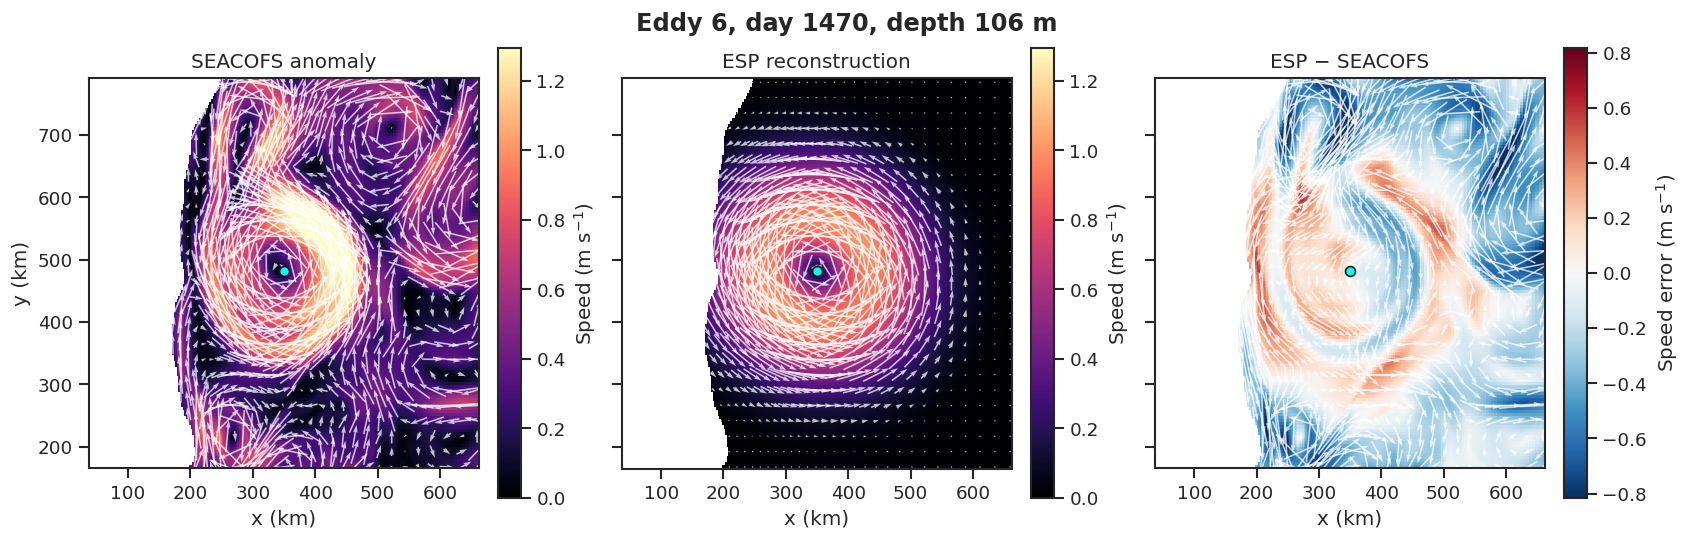

In [5]:
k = int(np.argmin(np.abs(depths - DEPTH_TO_PLOT)))
depth_plot = depths[k]
vmax = np.nanpercentile(np.r_[ds.speed_original[k].values.ravel(),
                              ds.speed_esp[k].values.ravel()], 99)
elim = max(np.nanpercentile(np.abs(ds.speed_error[k]), 99), 1e-12)
step = max(1, QUIVER_STEP)

fig, axs = plt.subplots(1, 3, figsize=(14, 4.4), sharex=True, sharey=True, constrained_layout=True)
panels = [
    (ds.speed_original[k], ds.u_original[k], ds.v_original[k], "SEACOFS anomaly"),
    (ds.speed_esp[k], ds.u_esp[k], ds.v_esp[k], "ESP reconstruction"),
    (ds.speed_error[k], ds.u_esp[k]-ds.u_original[k],
     ds.v_esp[k]-ds.v_original[k], "ESP − SEACOFS"),
]
for ax, (field, u, v, title) in zip(axs, panels):
    if "−" in title:
        mesh = ax.pcolormesh(X, Y, field, cmap="RdBu_r",
                             norm=TwoSlopeNorm(vcenter=0, vmin=-elim, vmax=elim), shading="auto")
        label = "Speed error (m s$^{-1}$)"
    else:
        mesh = ax.pcolormesh(X, Y, field, cmap="magma", vmin=0, vmax=vmax, shading="auto")
        label = "Speed (m s$^{-1}$)"
    ax.quiver(X[::step,::step], Y[::step,::step], u.values[::step,::step],
              v.values[::step,::step], color="white", alpha=.75, pivot="mid",
              scale=4.5, width=.004)
    ax.scatter(profile.iloc[k].xc, profile.iloc[k].yc, c="cyan", ec="k", s=35)
    ax.set(title=title, xlabel="x (km)", aspect="equal")
    fig.colorbar(mesh, ax=ax, label=label)
axs[0].set_ylabel("y (km)")
fig.suptitle(f"Eddy {int(surface.Eddy)}, day {int(surface.Day)}, depth {depth_plot:.0f} m",
             fontweight="bold")
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR/"horizontal_velocity_comparison.png", bbox_inches="tight")
plt.show()


## Pointwise agreement, vertical skill, and sections


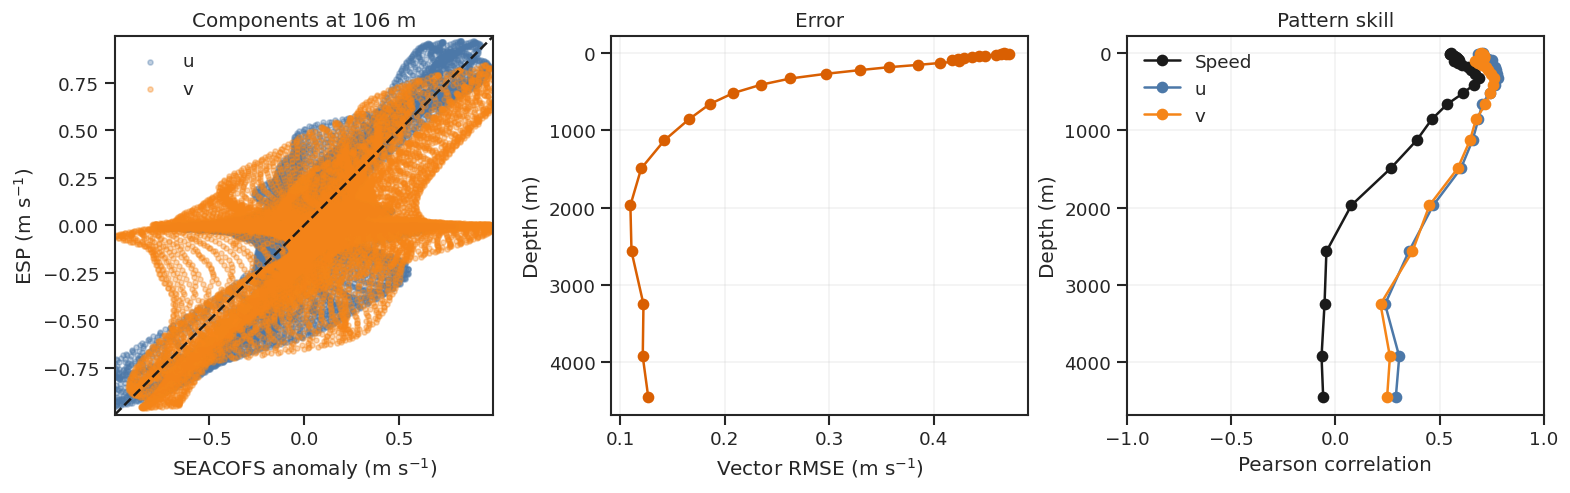

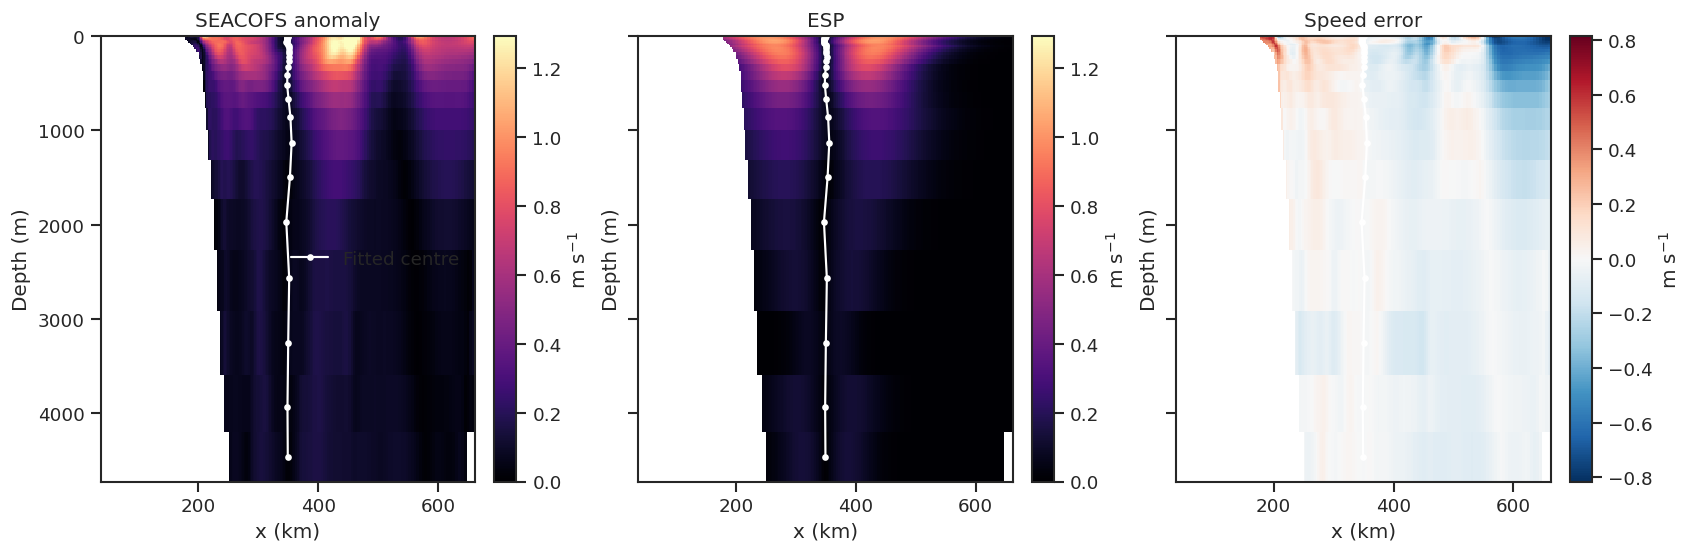

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
good = np.isfinite(u_obs[k]) & np.isfinite(v_obs[k])
for observed, modeled, label, color in [
    (u_obs[k][good], u_esp[k][good], "u", "#4c78a8"),
    (v_obs[k][good], v_esp[k][good], "v", "#f58518"),
]:
    axs[0].scatter(observed, modeled, s=9, alpha=.35, label=label, color=color)
limit = np.nanpercentile(np.abs(np.r_[u_obs[k][good], v_obs[k][good],
                                      u_esp[k][good], v_esp[k][good]]), 99)
axs[0].plot([-limit,limit], [-limit,limit], "k--")
axs[0].set(xlim=(-limit,limit), ylim=(-limit,limit), aspect="equal",
           xlabel="SEACOFS anomaly (m s$^{-1}$)", ylabel="ESP (m s$^{-1}$)",
           title=f"Components at {depth_plot:.0f} m")
axs[0].legend(frameon=False)
axs[1].plot(skill.Vector_RMSE_m_s, skill.Depth_m, "o-", color="#d95f02")
axs[1].set(xlabel="Vector RMSE (m s$^{-1}$)", ylabel="Depth (m)", title="Error")
for col, label, color in [("Speed_correlation","Speed","k"),
                           ("u_correlation","u","#4c78a8"), ("v_correlation","v","#f58518")]:
    axs[2].plot(skill[col], skill.Depth_m, "o-", label=label, color=color)
axs[2].set(xlim=(-1,1), xlabel="Pearson correlation", ylabel="Depth (m)", title="Pattern skill")
axs[2].legend(frameon=False)
for ax in axs[1:]:
    ax.invert_yaxis(); ax.grid(alpha=.25)
plt.show()

j_core = int(np.argmin(np.abs(ds.y.values-profile.iloc[0].yc)))
fig, axs = plt.subplots(1, 3, figsize=(14, 4.5), sharex=True, sharey=True, constrained_layout=True)
sections = [(ds.speed_original[:,:,j_core], "SEACOFS anomaly", "magma", 0, vmax),
            (ds.speed_esp[:,:,j_core], "ESP", "magma", 0, vmax),
            (ds.speed_error[:,:,j_core], "Speed error", "RdBu_r", -elim, elim)]
for ax, (field,title,cmap,vmin,vmax_) in zip(axs, sections):
    mesh = ax.pcolormesh(ds.x, depths, field, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax_)
    ax.plot(profile.xc, profile.Depth, "w.-", lw=1.3, label="Fitted centre")
    ax.set(title=title, xlabel="x (km)", ylabel="Depth (m)")
    ax.invert_yaxis(); fig.colorbar(mesh, ax=ax, label="m s$^{-1}$")
axs[0].legend(frameon=False)
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR/"vertical_sections.png", bbox_inches="tight")
plt.show()


## Three-dimensional velocity vectors

The decimated view shows horizontal vectors through the fitted water column; the red line is the fitted ESP centre.


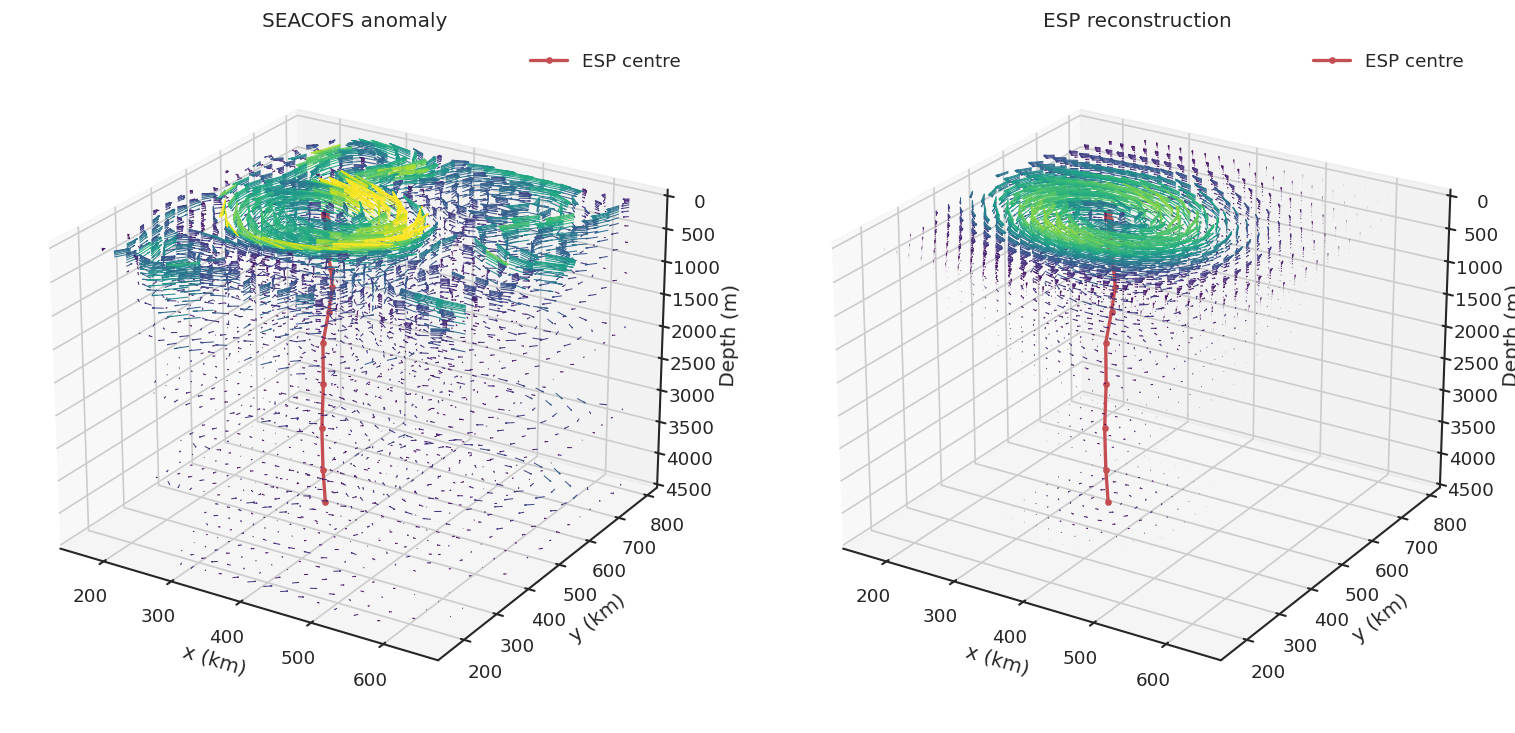

In [7]:
def plot_velocity_3d(ax, u, v, title, xy_step=7, z_step=2):
    xx, yy = X[::xy_step,::xy_step], Y[::xy_step,::xy_step]
    for iz in range(0, len(depths), z_step):
        uu, vv = u[iz,::xy_step,::xy_step], v[iz,::xy_step,::xy_step]
        good = np.isfinite(uu) & np.isfinite(vv)
        zz = np.full_like(xx, depths[iz], dtype=float)
        colors = plt.cm.viridis(np.clip(np.hypot(uu[good],vv[good])/max(vmax,1e-12),0,1))
        ax.quiver(xx[good],yy[good],zz[good],uu[good],vv[good],np.zeros(good.sum()),
                  length=55, colors=colors, arrow_length_ratio=.25, linewidth=.6)
    ax.plot(profile.xc,profile.yc,profile.Depth,"r.-",lw=2,label="ESP centre")
    ax.set(xlabel="x (km)",ylabel="y (km)",zlabel="Depth (m)",title=title)
    ax.invert_zaxis(); ax.view_init(elev=24,azim=-58); ax.legend(frameon=False)

fig = plt.figure(figsize=(13,6), constrained_layout=True)
plot_velocity_3d(fig.add_subplot(121,projection="3d"),u_obs,v_obs,"SEACOFS anomaly")
plot_velocity_3d(fig.add_subplot(122,projection="3d"),u_esp,v_esp,"ESP reconstruction")
if SAVE_FIGURES:
    fig.savefig(FIGURE_DIR/"velocity_structure_3d.png",bbox_inches="tight")
plt.show()


## Normalised Okubo–Weiss comparison

$$
W=s_n^2+s_s^2-\zeta^2,
\qquad s_n=u_x-v_y,\quad s_s=v_x+u_y,\quad \zeta=v_x-u_y.
$$

Negative $W$ indicates rotation-dominated flow. Both fields are divided by the standard deviation of the original local $W$ volume, giving one common reference. The $-0.2$ surface is a conventional illustrative boundary, not a universal eddy definition; test threshold sensitivity before quantitative use.


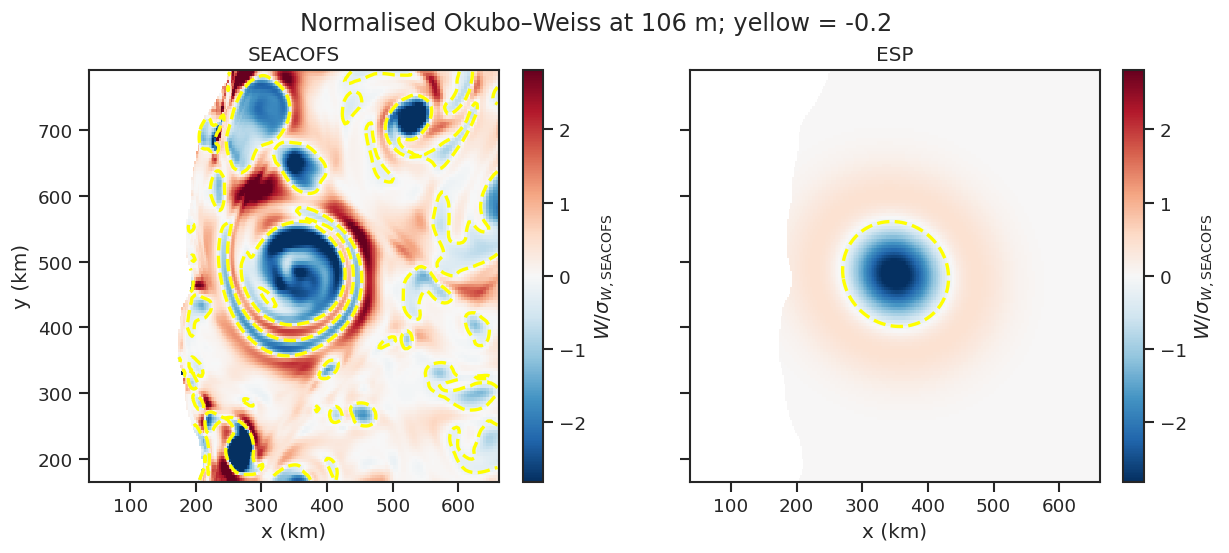

In [8]:
def okubo_weiss(u, v, x_km, y_km):
    output = np.full_like(u, np.nan, dtype=float)
    for iz in range(len(u)):
        du_dx,du_dy = np.gradient(u[iz],np.asarray(x_km)*1e3,np.asarray(y_km)*1e3,axis=(0,1))
        dv_dx,dv_dy = np.gradient(v[iz],np.asarray(x_km)*1e3,np.asarray(y_km)*1e3,axis=(0,1))
        sn,ss,zeta = du_dx-dv_dy,dv_dx+du_dy,dv_dx-du_dy
        output[iz] = sn**2+ss**2-zeta**2
    return output

ow_obs = okubo_weiss(u_obs,v_obs,ds.x.values,ds.y.values)
ow_esp = okubo_weiss(u_esp,v_esp,ds.x.values,ds.y.values)
ow_scale = np.nanstd(ow_obs)
if not np.isfinite(ow_scale) or ow_scale == 0:
    raise ValueError("Original Okubo–Weiss field has invalid variance.")
ow_obs_n,ow_esp_n = ow_obs/ow_scale,ow_esp/ow_scale
ds["ow_original_normalised"] = (("depth","x","y"),ow_obs_n)
ds["ow_esp_normalised"] = (("depth","x","y"),ow_esp_n)

owlim = np.nanpercentile(np.abs(np.r_[ow_obs_n[k].ravel(),ow_esp_n[k].ravel()]),98)
fig,axs = plt.subplots(1,2,figsize=(10.5,4.5),sharex=True,sharey=True,constrained_layout=True)
for ax,field,title in [(axs[0],ow_obs_n[k],"SEACOFS"),(axs[1],ow_esp_n[k],"ESP")]:
    mesh=ax.pcolormesh(X,Y,field,cmap="RdBu_r",vmin=-owlim,vmax=owlim,shading="auto")
    ax.contour(X,Y,field,levels=[OW_THRESHOLD],colors="yellow",linewidths=2)
    ax.set(title=title,xlabel="x (km)",aspect="equal")
    fig.colorbar(mesh,ax=ax,label=r"$W/\sigma_{W,\mathrm{SEACOFS}}$")
axs[0].set_ylabel("y (km)")
fig.suptitle(f"Normalised Okubo–Weiss at {depth_plot:.0f} m; yellow = {OW_THRESHOLD}")
plt.show()


### Interactive three-dimensional $-0.2$ isosurfaces

Plotly is optional. If it is missing, run `pip install plotly` once in the Katana environment.


In [9]:
try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    X3,Y3,Z3=np.meshgrid(ds.x.values,ds.y.values,depths,indexing="ij")
    fig=make_subplots(rows=1,cols=2,specs=[[{"type":"scene"},{"type":"scene"}]],
                      subplot_titles=("SEACOFS velocity anomaly","ESP reconstruction"))
    for col,field,color in [(1,np.moveaxis(ow_obs_n,0,-1),"RoyalBlue"),
                            (2,np.moveaxis(ow_esp_n,0,-1),"DarkOrange")]:
        fig.add_trace(go.Isosurface(
            x=X3.ravel(),y=Y3.ravel(),z=Z3.ravel(),value=field.ravel(),
            isomin=OW_THRESHOLD-.015,isomax=OW_THRESHOLD+.015,surface_count=1,
            opacity=.55,colorscale=[[0,color],[1,color]],showscale=False,
            caps=dict(x_show=False,y_show=False,z_show=False)),row=1,col=col)
        fig.add_trace(go.Scatter3d(x=profile.xc,y=profile.yc,z=profile.Depth,
            mode="lines+markers",line=dict(color="black",width=5),marker=dict(size=3),
            name="ESP centre",showlegend=(col==1)),row=1,col=col)
    scene=dict(xaxis_title="x (km)",yaxis_title="y (km)",zaxis_title="Depth (m)",
               zaxis=dict(autorange="reversed"),aspectmode="manual",
               aspectratio=dict(x=1,y=1,z=.75))
    fig.update_layout(scene=scene,scene2=scene,width=1100,height=620,
        title=f"Normalised Okubo–Weiss {OW_THRESHOLD} isosurfaces — "
              f"Eddy {int(surface.Eddy)}, day {int(surface.Day)}")
    fig.show()
except ImportError:
    print("Plotly is unavailable. Install it with: pip install plotly")


Plotly is unavailable. Install it with: pip install plotly


## Interpretation and export

Judge the reconstruction jointly from:

- location, ellipticity, rotation sense, and maximum-speed ring;
- component agreement, bias, RMSE, and depth-dependent correlation;
- vertical decay and movement of the fitted centre;
- whether ESP reproduces the coherent $-0.2$ Okubo–Weiss core while suppressing background filaments.

Okubo–Weiss is not an independent validation metric because ESP is intrinsically smooth and vortex-shaped. The pointwise velocities and vertical sections are the stronger quantitative evidence.


In [10]:
summary=pd.Series({
    "Eddy":int(surface.Eddy),"Day":int(surface.Day),"Polarity":getattr(surface,"Cyc",""),
    "NetCDF":model_file.name,"Fitted_depth_levels":len(depths),
    "Maximum_depth_m":float(np.max(depths)),
    "Median_vector_RMSE_m_s":float(skill.Vector_RMSE_m_s.median()),
    "Median_speed_correlation":float(skill.Speed_correlation.median()),
    "Background_removed":REMOVE_BACKGROUND,"OW_threshold":OW_THRESHOLD,
})
display(summary.to_frame("value"))
if SAVE_FIGURES:
    skill.to_csv(FIGURE_DIR/"depth_resolved_skill.csv",index=False)
    summary.to_csv(FIGURE_DIR/"case_summary.csv",header=["value"])
    print(f"Saved outputs to {FIGURE_DIR}")


,value
Eddy,6
Day,1470
Polarity,AE
NetCDF,outer_avg_01461.nc
Fitted_depth_levels,29
Maximum_depth_m,4460.447022
Median_vector_RMSE_m_s,0.357077
Median_speed_correlation,0.567743
Background_removed,True
OW_threshold,-0.2
